In [110]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

In [82]:
import numpy as np

def desired_axis(lon0,lon1,lat0,lat1):
    # lon0, lon1 = int,int
    # lat0, lat1 = int,int
    
    # 1) Use T-point lon/lat
    lonT = ds_Hgr.glamt.isel(t=0)
    latT = ds_Hgr.gphit.isel(t=0)
    
    # 2) Build boolean mask for your box
    mask = (lonT >= lon0) & (lonT <= lon1) & (latT >= lat0) & (latT <= lat1)
    
    # 3) Get index ranges
    yy, xx = np.where(mask.values)
    
    y0, y1 = int(yy.min()), int(yy.max())
    x0, x1 = int(xx.min()), int(xx.max())
    
    return x0, x1, y0, y1

In [24]:
pathUVW = Path('/work/bk1450/b383184/Amazon/Mercator/data/variables_c')

In [81]:
ds_Hgr = xr.open_dataset('../data/Hgr_mesh.nc')
ds_Hgr

<xarray.Dataset> Size: 1GB
Dimensions:       (y: 3059, x: 4322, z: 50, t: 1)
Dimensions without coordinates: y, x, z, t
Data variables: (12/21)
    nav_lon       (y, x) float32 53MB ...
    nav_lat       (y, x) float32 53MB ...
    nav_lev       (z) float32 200B ...
    time_counter  (t) float64 8B ...
    glamt         (t, y, x) float32 53MB ...
    glamu         (t, y, x) float32 53MB ...
    ...            ...
    e1f           (t, y, x) float64 106MB ...
    e2t           (t, y, x) float64 106MB ...
    e2u           (t, y, x) float64 106MB ...
    e2v           (t, y, x) float64 106MB ...
    e2f           (t, y, x) float64 106MB ...
    ff            (t, y, x) float64 106MB ...
Attributes:
    file_name:            mesh_hgr.nc
    TimeStamp:            03/02/2016 10:24:55 -0000
    Unlimited_Dimension:  t

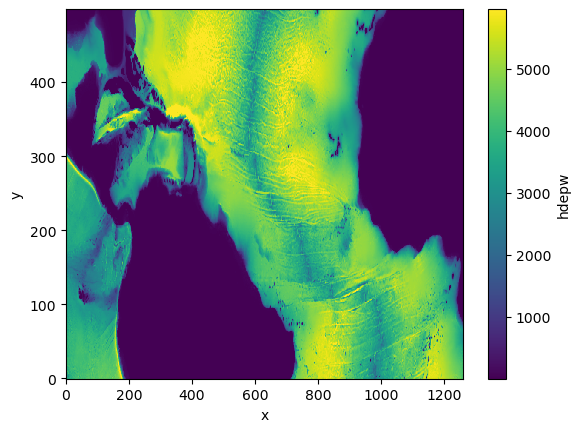

In [57]:
ds_Zgr = xr.open_dataset('../data/Zgr_cmesh.nc')
ds_Zgr.isel(t=0).hdepw.plot()
# ds_Zgr

In [25]:
ds_ssh = xr.open_dataset(pathUVW / "SSH_1993-01c.nc")
ds_ssh

<xarray.Dataset> Size: 83MB
Dimensions:       (time_counter: 31, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
Data variables:
    sossheig      (time_counter, y, x) float32 78MB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Nov 10 14:48:52 2025: cdo setmissval,nan SSH_1993-01.nc...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [26]:
ds_W = xr.open_dataset(pathUVW / "W_1993-01c.nc")
ds_W

<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB ...
    nav_lat       (y, x) float32 3MB ...
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float32 4GB ...
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:26:13 2025: cdo setmissval,nan W_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

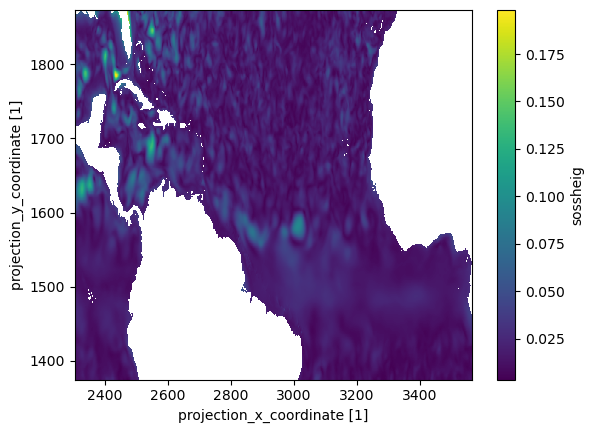

In [27]:
ds_ssh.sossheig.std("time_counter").plot()

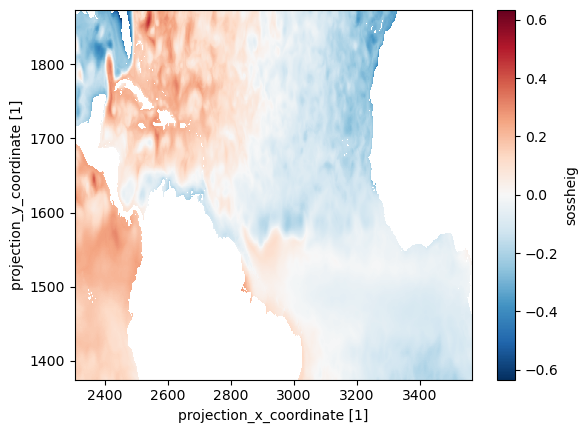

In [28]:
ds_ssh.sossheig.min("time_counter").plot()

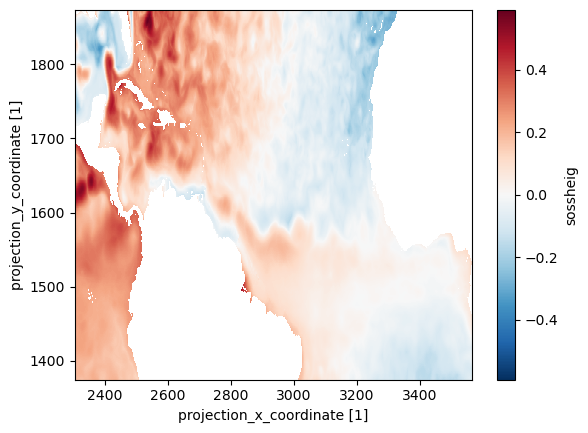

In [29]:
ds_ssh.sossheig.max("time_counter").plot()

In [30]:
(ds_ssh.sossheig.max("time_counter") - ds_ssh.sossheig.min("time_counter")).max()

<xarray.DataArray 'sossheig' ()> Size: 8B
array(0.89903367)

In [31]:
ds_ssh.sossheig.min()

<xarray.DataArray 'sossheig' ()> Size: 8B
array(-0.63362551)

In [32]:
ds_W.depthw.data[1]

np.float32(1.0112752)

For the dataset (time and region) that's safe: No eta intrusion into the second cell.

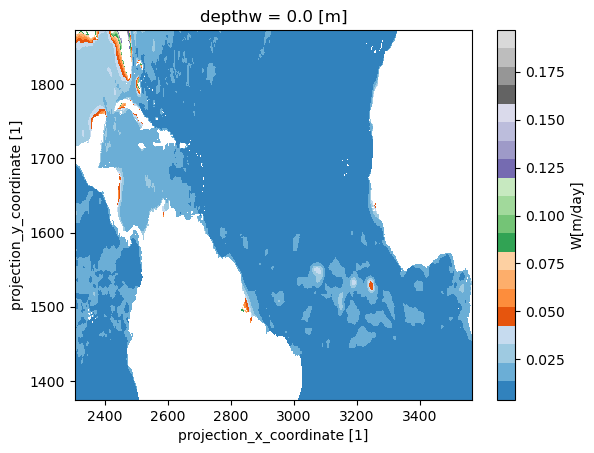

In [33]:
(ds_W.isel(depthw=0).std("time_counter").vovecrtz * 24 * 3600).rename("W[m/day]").plot(cmap='tab20c')

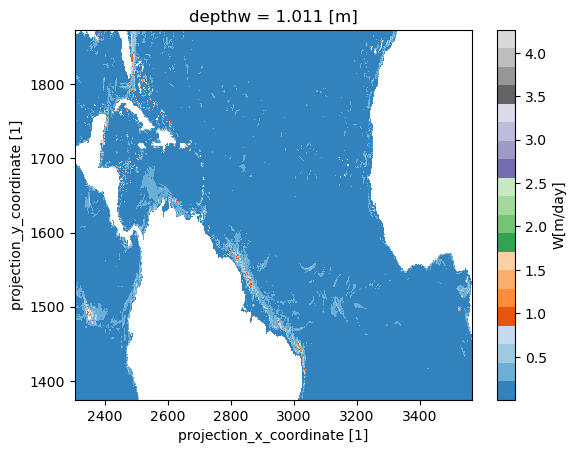

In [34]:
(ds_W.isel(depthw=1).std("time_counter").vovecrtz * 24 * 3600).rename("W[m/day]").plot(cmap='tab20c')

In [35]:
import numpy as np

Correlation of eta-movement with W through bottom of surface cell

--> Noisy: No systematic (anti-)correlation

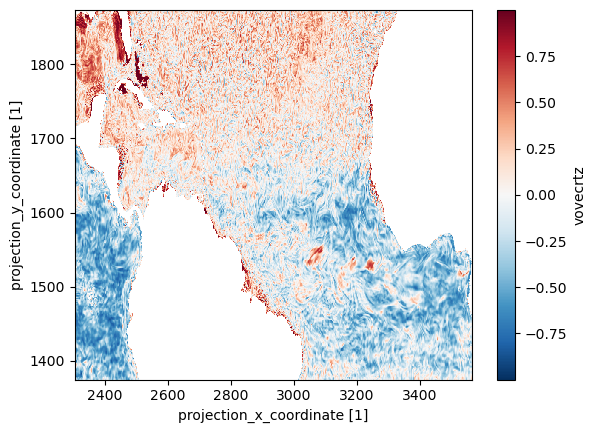

In [36]:
((
    (
        (ds_W.isel(depthw=0, drop=True) * ds_W.isel(depthw=1, drop=True)).mean("time_counter")
        - ds_W.isel(depthw=0, drop=True).mean("time_counter") * ds_W.isel(depthw=1, drop=True).mean("time_counter")
    ) 
    / ds_W.isel(depthw=0, drop=True).std("time_counter") / ds_W.isel(depthw=1, drop=True).std("time_counter")
)).vovecrtz.plot()

Correlation of W through bottom of 1st and 2nd cell from above.

--> systematic correlation

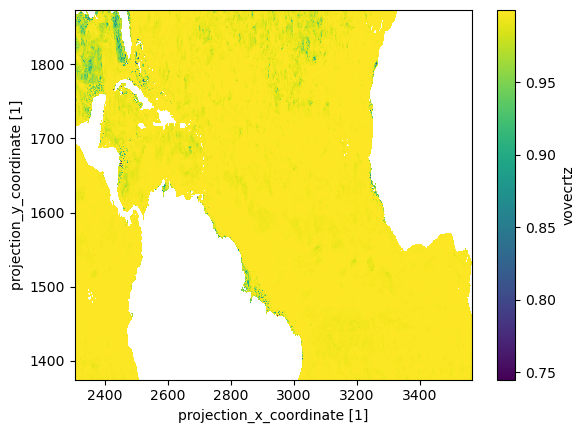

In [37]:
((
    (
        (ds_W.isel(depthw=2, drop=True) * ds_W.isel(depthw=1, drop=True)).mean("time_counter")
        - ds_W.isel(depthw=2, drop=True).mean("time_counter") * ds_W.isel(depthw=1, drop=True).mean("time_counter")
    ) 
    / ds_W.isel(depthw=2, drop=True).std("time_counter") / ds_W.isel(depthw=1, drop=True).std("time_counter")
)).vovecrtz.plot()

Conclude: eta only influeces W _within_ surface cell.

Hence: $W(z)$ is linearly interpolated between $d\eta/dt$ and $W$ of bottom of surface cell.

In [38]:
deta_dt = ds_W.isel(depthw=0, drop=True)

In [39]:
z = - ds_W.depthw  # pos upward

In [58]:
H = ds_Zgr.isel(t=0).hdepw # wrong!!!!  must come from mesh and be different for each x, y !!!

In [59]:
eta = ds_ssh.sossheig

In [60]:
W_eta = (z + H) / (eta + H) * deta_dt  # blows up.

In [61]:
W_eta  # W_due_to_movement_of_eta

<xarray.Dataset> Size: 8GB
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
Data variables:
    vovecrtz      (depthw, y, x, time_counter) float64 8GB -2.213e-08 ... nan

In [62]:
W_merc = ds_W.vovecrtz

In [63]:
W_fixed = W_merc - W_eta

In [64]:
W_fixed

<xarray.Dataset> Size: 8GB
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB -95.0 -94.92 -94.83 ... 9.764 9.847 9.93
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float64 8GB -9.641e-13 ... nan

In [ ]:
# test: 
# - W_fixed.isel(depthw=0) == 0 everywhere!
# - W_fixed.isel(depthw=bottom_k) == 0 everywhere!

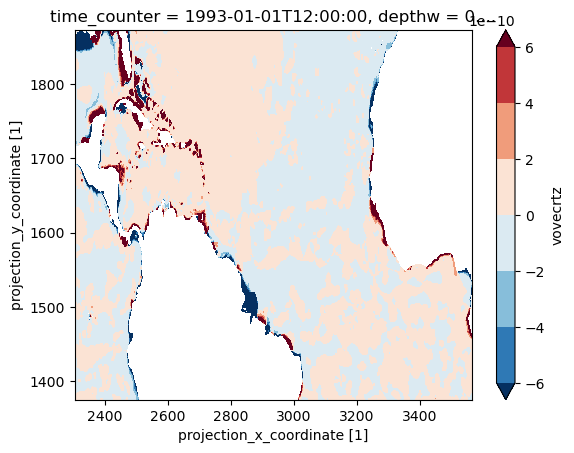

In [90]:
W_fixed.isel(depthw=0,time_counter=0).vovecrtz.plot.contourf(x='x', y='y',robust=True)

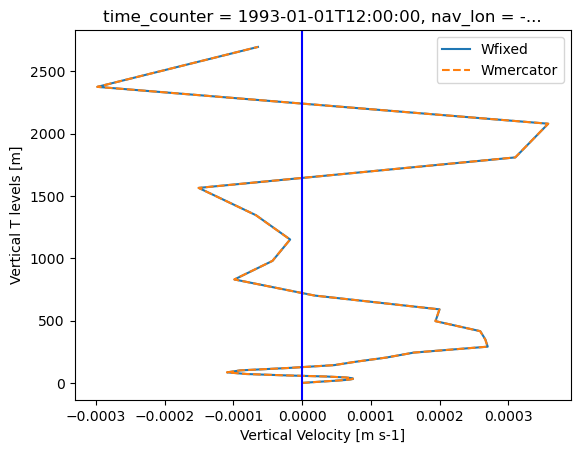

In [114]:
W_fixed.isel(time_counter=0).vovecrtz.isel(x=100,y=100).plot(y='depthw', label='Wfixed')
ds_W.isel(time_counter=0).vovecrtz.isel(x=100,y=100).plot(y='depthw',linestyle='--', label='Wmercator')
plt.axvline(x = 0, color = 'b')
plt.legend()

Text(0.5, 1.0, 'W_bottom')

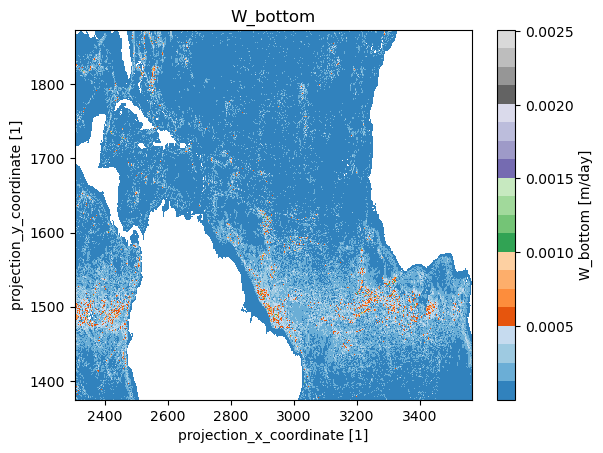

In [134]:
W_fixed.isel(depthw=ds_Zgr.mbathy-1).isel(t=0).std('time_counter').vovecrtz.rename('W_bottom [m/day]').plot(cmap='tab20c')
plt.title('W_bottom')

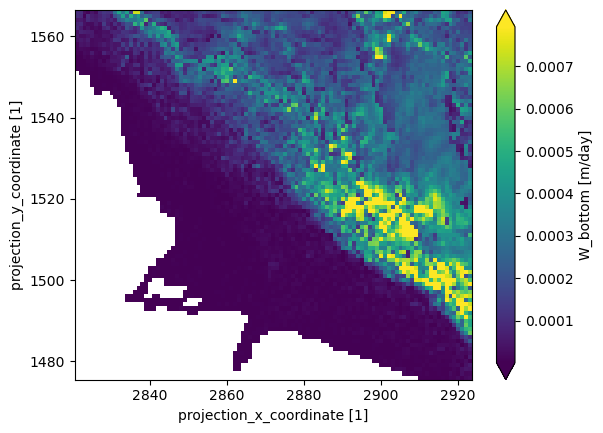

In [132]:
x0, x1, y0, y1 = desired_axis(-52, -43.5,-1.5,6)
W_fixed.isel(depthw=ds_Zgr.mbathy-1).isel(t=0).std('time_counter').vovecrtz.rename('W_bottom [m/day]').sel(x=slice(x0,x1),y=slice(y0,y1)).plot(robust=True)


Not zero at the bottom

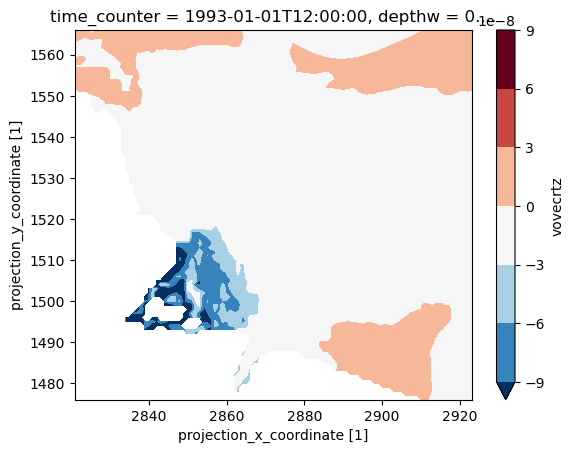

In [84]:
W_fixed.isel(depthw=0,time_counter=0).vovecrtz.sel(x=slice(x0,x1),y=slice(y0,y1)).plot.contourf(x='x', y='y',robust=True)

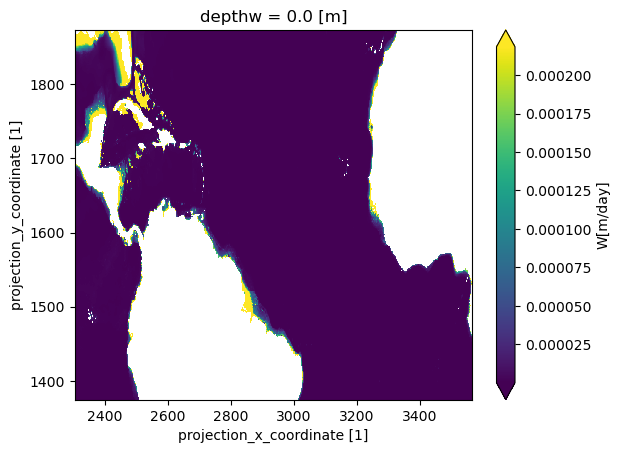

In [97]:
(W_fixed.isel(
    depthw=0).std('time_counter').vovecrtz* 24 * 3600).rename("W[m/day]").plot(robust=True)

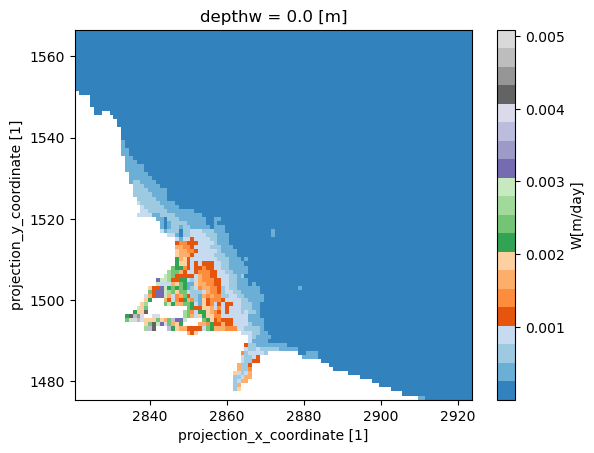

In [96]:
# * 24 * 3600).rename("W[m/day]").plot(cmap='tab20c')
(W_fixed.isel(
    depthw=0).std('time_counter').vovecrtz.sel(x=slice(x0,x1),y=slice(y0,y1))* 24 * 3600).rename("W[m/day]").plot(cmap='tab20c')

In [136]:
W_fixed.to_netcdf('W_1993-01f.nc')